<a href="https://colab.research.google.com/github/AllenGeorge08/NeuralNetworksFromScratch/blob/master/MicrogradFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch matplotlib numpy math

ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math


In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
class Value:
  def __init__(self,data,_children=(),_op='',label='',grad=0):
    self.grad = 0
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label
    self._backward = lambda: None


  def __repr__(self):
    return f"Value (data: {self.data})"


  def __add__(self,other):
    other = other if isinstance(other,Value ) else Value(other)
    out = Value(self.data+other.data,(self,other),_op='+')
    def _backward():  # to backpropogate through child gradients
      self.grad += 1.0*out.grad
      other.grad += 1.0*out.grad
    out._backward = _backward
    return out


  def __radd__(self,other):
    return self+other


  def __mul__(self,other):
    other = other if isinstance(other,Value) else Value(other)
    out = Value(self.data*other.data,(self,other),_op='*')
    def _backward():
      self.grad += out.grad*other.data
      other.grad += out.grad*self.data
    out._backward = _backward
    return out


  def __rmul__(self,other):
    return self*other


  def __sub__(self,other):
    return self + (-other)


# tanh(x) = (e**x-e**-x)/(e**x+e**-x) = (e**2x-1)/(e**2x+1) ..here're we're taking tanh(n)

  def tanh(self):
      n = self.data
      t = (math.exp(2*n)-1)/(math.exp(2*n)+1)
      out = Value(t,(self,),label='tanh')
      def _backward():
        self.grad += (1-t**2)*out.grad
      out._backward = _backward
      return out


  def exp(self):
    x = self.data
    out = Value(math.exp(x),(self,),label='exp')

    def _backward():
      self.grad  += out.data*out.grad #dl/dx = dl/dout*dout/dx = e**x * out.grad
    out._backward = _backward
    return out


  def __pow__(self,other):
    assert isinstance(other,(int,float)),"Only supporting int and float powers"
    out = Value(self.data**other,(self,),label=f'**{other}')
    def _backward():
      self.grad += (other*(self.data**(other-1)))*out.grad  #out = x**n , dL/dx = dL/dout*dout/dx ...= out.grad * (nx**n-1)
    out._backward = _backward
    return out


  def __true__div__(self,other):
    return self*(other**-1)


  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    # topo
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [37]:
from graphviz import Digraph

def trace(root):
  nodes,edges=set(),set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child,v))
        build(child)
  build(root) # Corrected indentation
  return nodes,edges # Corrected indentation


def draw_dot(root,format='svg',rankdir='LR'):

  nodes,edges=trace(root)
  dot=Digraph(format=format,graph_attr={'rankdir': rankdir})

  for n in nodes:
    uid  =str(id(n))
    dot.node(name=uid,label="{%s | data : %.4f | grad : %.4f}"%(n.label,n.data,n.grad),shape='record')
    if n._op:
      dot.node(name=uid+n._op, label=n._op)
      dot.edge(uid + n._op , str(id(n)))


  for n1,n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)


  return dot

In [38]:
import random

# if nin = 3, we create w=[w1,w2,w3]..one neuron one bias
# z = w1x1 + w2x2 +w3x3 +b
class Neuron:
  def __init__(self,nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b  = Value(random.uniform(-1,1))

  # act = w1x1+w2x2+w3x3..
  # out = tanh(act)
  def __call__(self,x):
    act = sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out = act.tanh()
    return out

  # Gives us all the things the neuron ened to learn... .. during trainign w<- w- learning_rate*dL/dw
  # b <- b-learning_rate*dL/db
  def parameters(self):
    return self.w+[self.b]



# Multiple neurons.. 3 inputs -> 4 neurons
# [1,2,3] input -> [Neuron(1),Neuron(2),Neuron(3),Neuron(4)]
class Layer:
  def __init__(self,nin,nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self,x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs)==1 else outs

  # Collectss all weights and biases from all neurons
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]


# MLP(3,[4,2,1])
# Means 3 inputs -> 4 neurons -> 2 neurons -> 1 neuron
# size = 3+[4,2,1] -> [3,4,2,1]

class MLP:
  def __init__(self,nin,nouts):
    size = [nin]+nouts
    # i = 0, Layer(size[0],size[1]) = Layer(3,4), i=1, Layer=(4,2), i=2 , Layer=(2,1)...
    self.layers = [Layer(size[i],size[i+1]) for i in range(len(nouts))]

  # Forward pass ..take the input ,pass it through layer 1 , take it and pass it to layer 2 then 3..
  def __call__(self,x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]





In [73]:
x = [2.0,3.0]
n = MLP(3,[4,4,1])
n(x)
# type(n)

Value (data: -0.08070391559165166)

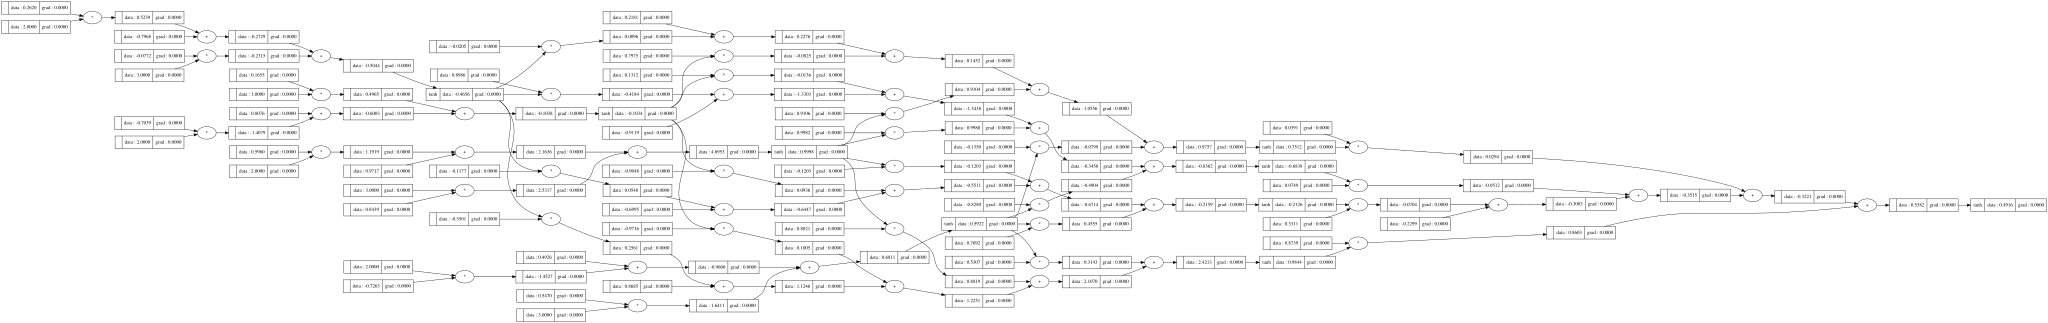

In [40]:
draw_dot(n(x))

In [74]:
yp = n(x)

# Zero out all gradients before backward pass
for p in n.parameters():
    p.grad = 0.0

# Perform backward pass to compute gradients
yp.backward()

# Now, the gradients are stored in the 'grad' attribute of each parameter
print("Gradients of MLP parameters after backward pass:")
for i, p in enumerate(n.parameters()):
    print(f"Parameter {i}: data={p.data:.4f}, grad={p.grad:.4f}")

Gradients of MLP parameters after backward pass:
Parameter 0: data=-0.1552, grad=-0.2528
Parameter 1: data=0.2400, grad=-0.3792
Parameter 2: data=-0.7129, grad=0.0000
Parameter 3: data=0.4649, grad=-0.1264
Parameter 4: data=-0.2553, grad=0.0930
Parameter 5: data=0.3479, grad=0.1395
Parameter 6: data=0.6746, grad=0.0000
Parameter 7: data=-0.0356, grad=0.0465
Parameter 8: data=-0.4688, grad=0.0359
Parameter 9: data=-0.0597, grad=0.0538
Parameter 10: data=0.5847, grad=0.0000
Parameter 11: data=-0.7045, grad=0.0179
Parameter 12: data=-0.3616, grad=-0.0027
Parameter 13: data=-0.6799, grad=-0.0041
Parameter 14: data=0.8409, grad=0.0000
Parameter 15: data=0.9687, grad=-0.0014
Parameter 16: data=-0.0835, grad=-0.1111
Parameter 17: data=-0.6541, grad=-0.0727
Parameter 18: data=-0.1809, grad=0.1498
Parameter 19: data=0.2508, grad=0.1494
Parameter 20: data=0.2198, grad=-0.1579
Parameter 21: data=0.6952, grad=-0.2408
Parameter 22: data=0.3093, grad=-0.1574
Parameter 23: data=-0.3594, grad=0.3247
P

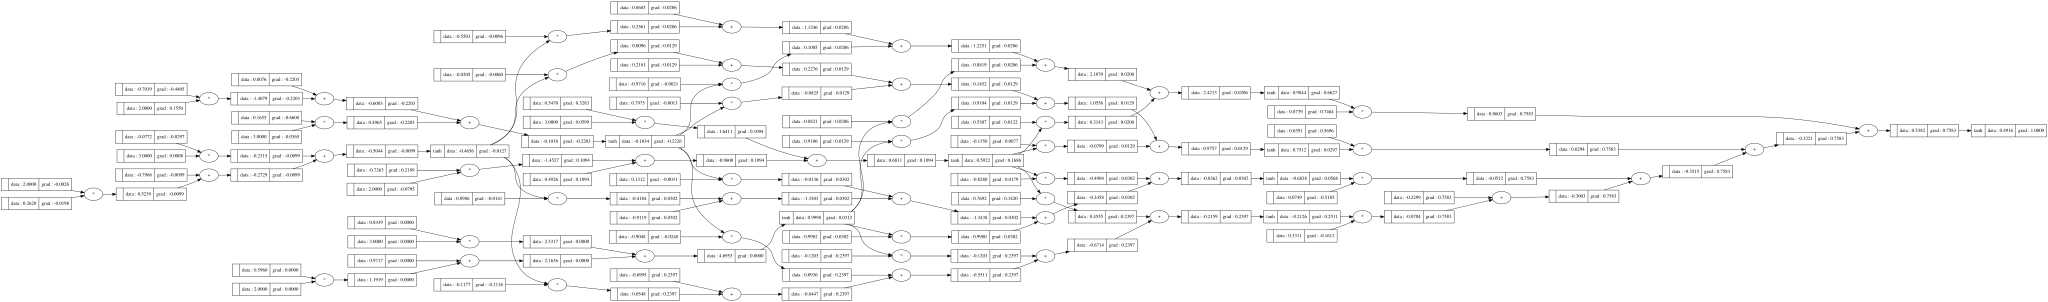

In [42]:
draw_dot(yp)

In [75]:
# Training data for MLP, 4 training exampless with 3 input features
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]


# input shape is 4x3
# correct ansswers for those 4 example
ys = [1.0, -1.0, -1.0, 1.0]


In [76]:
for k in range(100):
  y_pred = [n(x) for x in xs]
  loss = sum((yout-ygt)**2 for ygt,yout in zip(ys,y_pred))

  for p in n.parameters():
    p.grad = 0.0  #after the backward pass, weights contain gradients from the prev pass..
  loss.backward()

  # update the gradients/gradient desscent.. w_new=w_old-learning_rate
  for p in n.parameters():
    p.data += -0.05*p.grad
  print(k,loss.data)

0 5.939683898672048
1 4.27248973393486
2 3.558404520879561
3 2.9666120060728347
4 2.313757767912186
5 1.6474948165796834
6 1.1030857183007097
7 0.7379937142304727
8 0.5135893934467308
9 0.3752327816895368
10 0.28648277609674827
11 0.22687736138563927
12 0.18511193644164353
13 0.15474766140998253
14 0.13196384775047942
15 0.11440011903974985
16 0.10054352553014057
17 0.0893917426944382
18 0.08026088309765968
19 0.07267190597576326
20 0.06628128899708721
21 0.06083745928331284
22 0.05615267433574002
23 0.05208442888815868
24 0.04852288564863188
25 0.04538220483961974
26 0.04259445155006067
27 0.04010524128380097
28 0.037870578958487444
29 0.035854531129615216
30 0.03402748899310923
31 0.03236485629624144
32 0.030846046936682872
33 0.029453711071550634
34 0.028173131782588616
35 0.026991750410647147
36 0.025898789934412372
37 0.024884953759344915
38 0.02394218301855586
39 0.023063459649101854
40 0.02224264555774898
41 0.021474350447859336
42 0.020753822565010828
43 0.02007685788881942
44 

In [77]:
n.layers[0].neurons[0].w[0].grad

0.001614593552517691

In [79]:
n.layers[0].neurons[0].w[0].data


-0.273933222776113